# Q2. Unsupervised Learning

### Why scaling is essential?
K-Means is a distance-based algorithm that uses Euclidean distance. If features are on different scales, variables with larger values will dominate the clustering process.

Scaling ensures that all features contribute equally to distance calculations, leading to more meaningful and balanced clusters.

In [9]:
# Task 1 -  Data Preparation

import pandas as pd
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("../data/q2_customers.csv")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

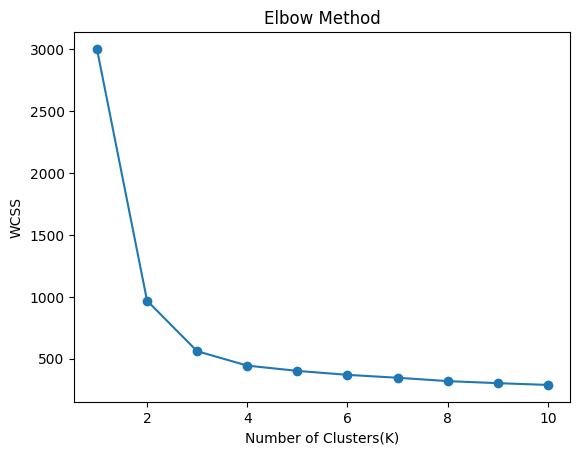

In [10]:
# Task 2 - Choosing K — Elbow Method

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters(K)")
plt.ylabel("WCSS")
plt.show()

### Optimal number of clusters (K)

From the elbow plot, the WCSS decreases sharply until K = 3, after which the rate of decrease slows down.

This point represents the "elbow", indicating that adding more clusters does not significantly improve the model.

Hence, the optimal number of clusters is chosen as K = 3

In [11]:
# Task 3 - K-Means Clustering

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df['cluster'] = clusters

# CLuster centers
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.columns[:-1]
)

centroids

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,56.769697,89413.333333,2.527273,5530.545455,105.357576,7.515152
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242


### Cluster interpretation

1) **Cluster 0**: Customers with lower spending and fewer visits -> Low-value customers
2) **Cluster 1**: Customers with high spending and frequesnt visits -> High-value customers
3) **Cluster 2**: Customers with moderate spending and average visit frequency -> Medium-value customers

These segments can help businesses target customers with personalized marketing strategies

In [12]:
# Task 4 - Dimensionality Reduction with PCA

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ration: ", pca.explained_variance_ratio_)

# Loadings
loadings = pd.DataFrame(
    pca.components_,
    columns=df.columns[:-1],
    index=['PC1', 'PC2']
)

loadings

Explained variance ration:  [0.83560354 0.05568764]


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.411569,0.42154,-0.410399,0.412012,0.378582,0.414017
PC2,-0.259432,-0.03327,0.208318,-0.195402,0.911194,-0.140479


### PCA Interpretation

1) PC1 captures the maximum variance in the dataset, mainly influenced by features like spending and visits
2) PC2 captures the second highest variance, representing additional variation not captured by PC1

In [ ]:
# Task 5 - Cluster Visualisation

plt.scatter(X_pca[:, 0], X_pca[:, 1], c = df['cluster'])
plt.title("Customer Segments(PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label='Cluster')
plt.show()